# Disque 100 em Santa Catarina: o que os dados sustentam

Analise dos microdados abertos do Disque 100 para Santa Catarina, de 2011 a 2026,
que sustenta o painel em `streamlit_app/`.

O objetivo deste notebook nao e apresentar o maior numero possivel, e sim
estabelecer **o que cada numero significa e sob quais condicoes ele e comparavel**.
Os microdados do Disque 100 tem tres propriedades que, ignoradas, produzem
conclusoes erradas com aparencia de solidez:

1. a linha do arquivo nao e uma denuncia;
2. o esquema muda tres vezes ao longo da serie, e com ele o que e mensuravel;
3. as taxas por habitante dividem contagens de varios anos por um estoque
   populacional de um unico ano.

As secoes a seguir medem cada uma dessas propriedades antes de qualquer
interpretacao substantiva.

## Roteiro

1. Ambiente e base analitica
2. Granularidade: registro de violacao e denuncia
3. As tres eras de esquema
4. Cobertura dos indicadores por semestre
5. Validacao contra o balanco oficial do MDHC
6. Triagem entre indicio penal e demanda socioassistencial
7. Demografia, taxas e o problema dos numeros pequenos
8. Acesso a pericia forense
9. Sintese, reconciliacao e limitacoes

## 1. Ambiente e base analitica

O notebook le a base ja materializada em DuckDB, e nao os arquivos brutos. Assim a
analise e o painel enxergam exatamente os mesmos numeros: qualquer divergencia
entre os dois seria erro de um dos lados, nao diferenca de metodo.

Reproduzir a base, a partir da raiz do projeto:

```
python3 scripts/gerar_banco_duckdb_sc.py
python3 scripts/build_annual_kpis.py
python3 scripts/gerar_geo_pci_sc.py
python3 scripts/analisar_distribuicao_penal_sc.py
```

In [1]:
from pathlib import Path
import json
import sys

import duckdb
import pandas as pd
import plotly.express as px
import plotly.io as pio

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pio.templates.default = "plotly_white"

# Cada figura e gravada nas duas formas na mesma saida de celula:
#   - "plotly_mimetype" grava o grafico interativo, que o JupyterLab usa para
#     dar zoom, isolar series e ler valores no ponto;
#   - "png" grava uma imagem estatica.
# As duas formas ficam no MESMO pacote de saida da celula. O GitHub nao suporta
# o formato interativo do Plotly em .ipynb e exibiria os graficos em branco;
# tendo as duas, ele cai para o PNG, enquanto o JupyterLab escolhe o
# interativo, por ser a representacao mais rica disponivel.
pio.renderers.default = "plotly_mimetype+png"
pio.defaults.default_width = 1000
pio.defaults.default_height = 420
pio.defaults.default_scale = 2

RAIZ = Path.cwd()
if not (RAIZ / "data").exists() and (RAIZ.parent / "data").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "scripts"))

BANCO = RAIZ / "data" / "database" / "sc_disque100_analitico.duckdb"
PROCESSADOS = RAIZ / "data" / "processed"

con = duckdb.connect(str(BANCO), read_only=True)
consultar = lambda sql: con.execute(sql).fetchdf()

with open(PROCESSADOS / "sc_relatorio_auditoria_dados.json", encoding="utf-8") as f:
    AUDITORIA = json.load(f)

print(f"Raiz do projeto: {RAIZ}")
print(f"Base analitica: {BANCO.relative_to(RAIZ)} ({BANCO.stat().st_size / 1024**2:.1f} MB)")
print(f"Processada em: {AUDITORIA['timestamp_auditoria']}")
print()
print("Tabelas:")
for (nome,) in con.execute("SHOW TABLES").fetchall():
    n = con.execute(f'SELECT COUNT(*) FROM "{nome}"').fetchone()[0]
    print(f"  {nome:<32s} {n:>9,} linhas")

Raiz do projeto: /Users/danrleyribeiro/Downloads/group-03-files
Base analitica: data/database/sc_disque100_analitico.duckdb (28.3 MB)
Processada em: 2026-09-14 14:50:03

Tabelas:
  dim_municipios                         295 linhas
  dim_unidades_pci                        30 linhas
  fato_denuncias                     699,029 linhas
  kpis_categoria_penal                 1,877 linhas
  kpis_grupos_municipios                 295 linhas
  kpis_grupos_municipios_ano           5,323 linhas


In [2]:
# Totais de referencia. Toda afirmacao do notebook e do painel se reconcilia
# com estes numeros.
totais = AUDITORIA["totais"]
for chave, valor in totais.items():
    if isinstance(valor, (int, float)):
        print(f"{chave:<42s} {valor:>12,}")
    else:
        print(f"{chave:<42s} {valor:>12}")

registros_de_violacao                           699,029
registros_penal                                 429,137
registros_social                                269,892
pct_penal                                         61.39
denuncias_unicas_identificaveis                  95,258
registros_com_denuncia_identificavel            605,002
periodo                                     2011 a 2026


## 2. Granularidade: registro de violacao e denuncia

Este e o ponto de partida, porque condiciona tudo o que vem depois.

Cada linha dos microdados e uma combinacao de **violacao, vitima e suspeito**. Uma
denuncia com tres vitimas e quatro tipos de violacao ocupa varias linhas. A coluna
`hash`, presente a partir do segundo semestre de 2020, identifica a denuncia e
permite separar as duas contagens.

A consequencia pratica e que **contar linhas nao e contar denuncias**, e a razao
entre as duas nao e constante: cresce ao longo da serie e varia entre municipios.
Uma serie temporal de contagem de linhas mistura, portanto, mudanca de demanda com
mudanca de registro.

In [3]:
por_ano = consultar("""
    SELECT ano,
           COUNT(*) AS registros_violacao,
           COUNT(DISTINCT CASE WHEN grain_denuncia_confiavel = 1 THEN id_denuncia END)
               AS denuncias_unicas,
           COUNT(DISTINCT semestre) AS semestres
    FROM fato_denuncias GROUP BY ano ORDER BY ano
""")
# `replace(0, float("nan"))` mantem a coluna em float64; com pd.NA o dtype
# viraria object e `round` falharia.
por_ano["registros_por_denuncia"] = (
    por_ano["registros_violacao"] / por_ano["denuncias_unicas"].replace(0, float("nan"))
).round(2)
por_ano["cobertura"] = por_ano.apply(
    lambda r: "parcial" if (r["semestres"] == 1 and r["ano"] >= 2020) else "completa", axis=1
)
por_ano

,ano,registros_violacao,denuncias_unicas,semestres,registros_por_denuncia,cobertura
0,2011,2697,0,1,NaN,completa
1,2012,10492,0,1,NaN,completa
2,2013,14106,0,1,NaN,completa
3,2014,11601,0,1,NaN,completa
4,2015,9803,0,1,NaN,completa
5,2016,9404,0,1,NaN,completa
6,2017,10118,0,1,NaN,completa
7,2018,9827,0,1,NaN,completa
8,2019,11432,0,1,NaN,completa
9,2020,12490,3474,2,3.60,completa


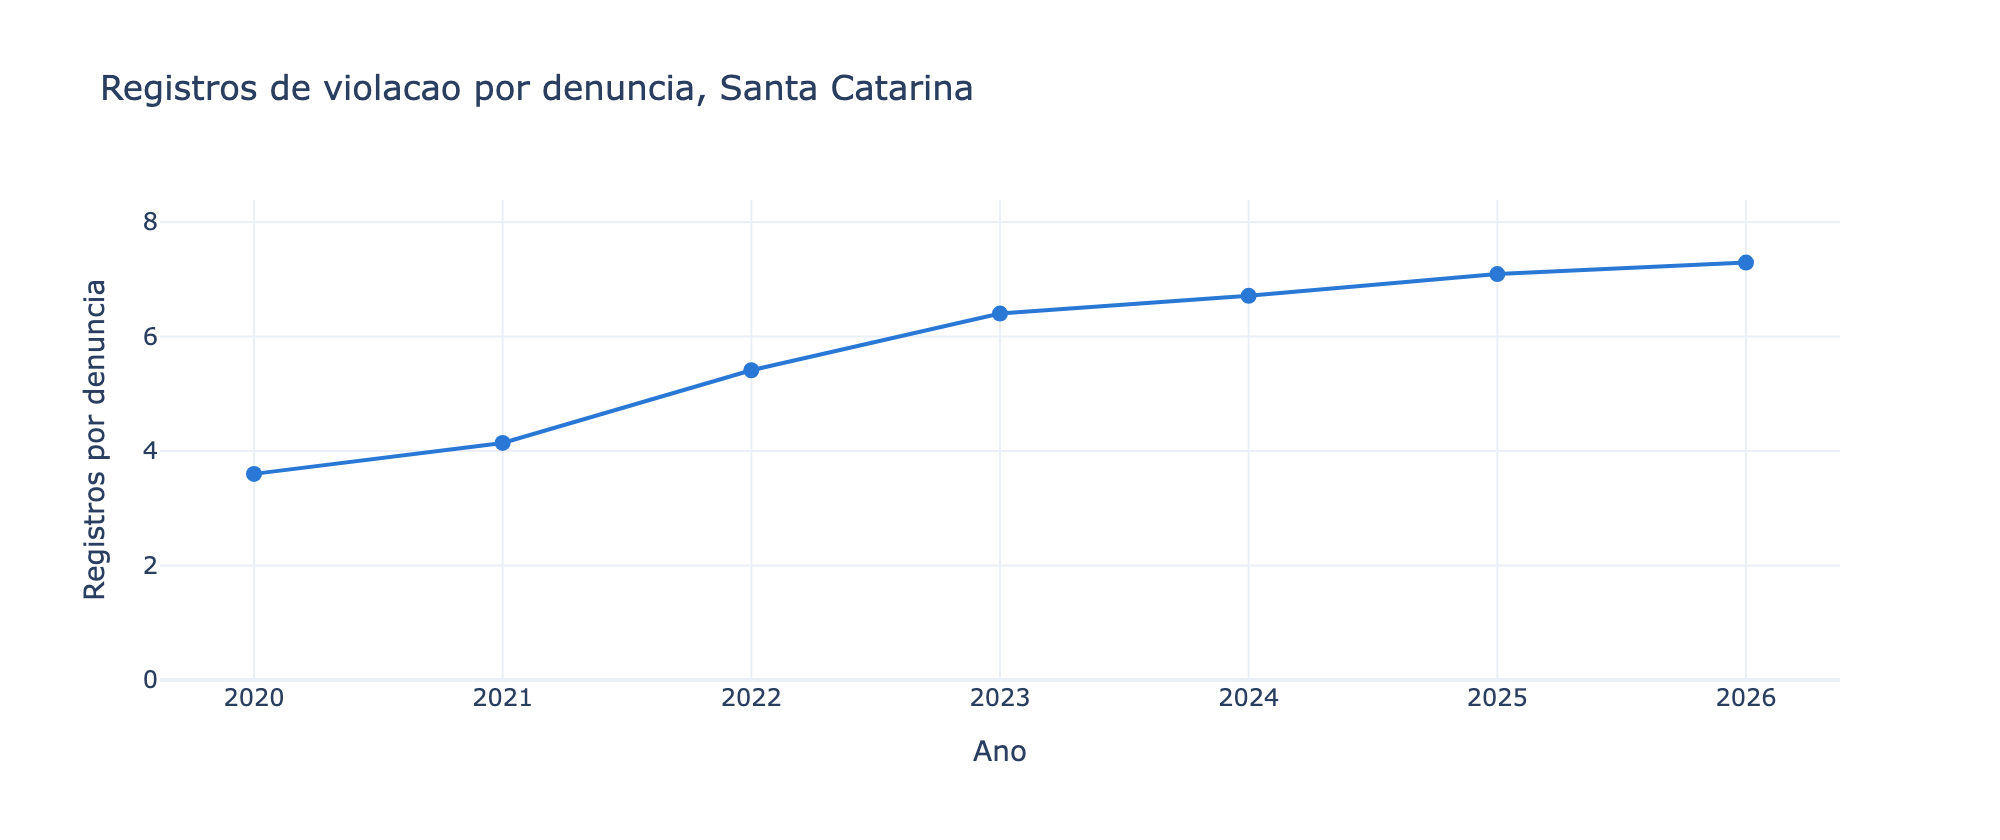

De 2020 a 2026, o fator passou de 3.6 para 7.29, multiplicando-se por 2.0.


In [4]:
# O fator de expansao mais que triplicou entre 2020 e 2026.
comparavel = por_ano.dropna(subset=["registros_por_denuncia"])
fig = px.line(
    comparavel, x="ano", y="registros_por_denuncia", markers=True,
    title="Registros de violacao por denuncia, Santa Catarina",
    labels={"ano": "Ano", "registros_por_denuncia": "Registros por denuncia"},
)
fig.update_traces(line_color="#2a78d6", line_width=2, marker_size=8)
fig.update_layout(yaxis_range=[0, comparavel["registros_por_denuncia"].max() * 1.15])
fig.show()

primeiro, ultimo = comparavel.iloc[0], comparavel.iloc[-1]
print(
    f"De {int(primeiro['ano'])} a {int(ultimo['ano'])}, o fator passou de "
    f"{primeiro['registros_por_denuncia']} para {ultimo['registros_por_denuncia']}, "
    f"multiplicando-se por {ultimo['registros_por_denuncia'] / primeiro['registros_por_denuncia']:.1f}."
)

In [5]:
# Crescimento aparente contra crescimento em denuncias, no periodo em que as
# duas contagens existem.
base = comparavel.iloc[0]
fim = comparavel[comparavel["cobertura"] == "completa"].iloc[-1]
cresc_registros = fim["registros_violacao"] / base["registros_violacao"]
cresc_denuncias = fim["denuncias_unicas"] / base["denuncias_unicas"]

print(f"Entre {int(base['ano'])} e {int(fim['ano'])}, em Santa Catarina:")
print(f"  registros de violacao  x{cresc_registros:.2f}")
print(f"  denuncias unicas       x{cresc_denuncias:.2f}")
print()
print(
    f"Parte do crescimento medido em registros e expansao de registro, nao de demanda: "
    f"a razao entre os dois crescimentos e {cresc_registros / cresc_denuncias:.2f}."
)

Entre 2020 e 2025, em Santa Catarina:
  registros de violacao  x13.74
  denuncias unicas       x6.96

Parte do crescimento medido em registros e expansao de registro, nao de demanda: a razao entre os dois crescimentos e 1.97.


In [6]:
# A dispersao entre municipios e o que inviabiliza o ranking por contagem de linha.
expansao_mun = consultar("""
    SELECT municipio_nome AS municipio,
           COUNT(*) AS registros,
           COUNT(DISTINCT id_denuncia) AS denuncias
    FROM fato_denuncias
    WHERE grain_denuncia_confiavel = 1
    GROUP BY 1 HAVING COUNT(DISTINCT id_denuncia) >= 30
""")
expansao_mun["fator"] = (expansao_mun["registros"] / expansao_mun["denuncias"]).round(2)

print(f"{len(expansao_mun)} municipios com ao menos 30 denuncias identificaveis")
print(expansao_mun["fator"].describe()[["min", "50%", "max"]].round(2).to_string())
print()
print("Cinco maiores fatores:")
print(expansao_mun.nlargest(5, "fator")[["municipio", "registros", "denuncias", "fator"]].to_string(index=False))
print()
print("Cinco menores fatores:")
print(expansao_mun.nsmallest(5, "fator")[["municipio", "registros", "denuncias", "fator"]].to_string(index=False))
print()
print(
    "Dois municipios com o mesmo numero de denuncias podem diferir em mais de duas "
    "vezes na contagem de registros. Rankings municipais por registro medem, em parte, "
    "a complexidade das denuncias, e nao o volume de demanda."
)

237 municipios com ao menos 30 denuncias identificaveis
min    4.53
50%    6.30
max    9.88

Cinco maiores fatores:
      municipio  registros  denuncias  fator
São João do Sul       1196        121   9.88
     Entre Rios        430         45   9.56
       Arvoredo        368         40   9.20
       Maracajá       1339        147   9.11
   Morro Grande        337         40   8.43

Cinco menores fatores:
  municipio  registros  denuncias  fator
Cerro Negro        136         30   4.53
     Salete        253         55   4.60
   Angelina        323         69   4.68
  Água Doce        446         93   4.80
 Mirim Doce        221         46   4.80

Dois municipios com o mesmo numero de denuncias podem diferir em mais de duas vezes na contagem de registros. Rankings municipais por registro medem, em parte, a complexidade das denuncias, e nao o volume de demanda.


## 3. As tres eras de esquema

Os 22 arquivos publicados pelo MDHC nao seguem um esquema estavel. Ha tres eras, e a
mesma informacao aparece com grafias diferentes: a coluna de genero da vitima, por
exemplo, tem cinco grafias ao longo da serie, e o arquivo do primeiro semestre de
2023 nao traz a coluna de grupo vulneravel.

Ler essas colunas por nome literal deixa de fora metade da serie. O pipeline resolve
cada campo por uma lista de grafias normalizadas, em
`scripts/colunas_disque100.py`, e registra no relatorio de auditoria o que nao
encontrou em cada arquivo. E isso que a tabela abaixo mostra.

In [7]:
inventario = pd.DataFrame(AUDITORIA["inventario_arquivos"])
colunas = [
    "arquivo", "era_esquema", "colunas_no_arquivo", "linhas_sc",
    "linhas_sc_distintas", "denuncias_sc_distintas",
    "fator_expansao_linhas_por_denuncia",
]
inventario[[c for c in colunas if c in inventario.columns]].sort_values("arquivo")

,arquivo,era_esquema,colunas_no_arquivo,linhas_sc,linhas_sc_distintas,denuncias_sc_distintas,fator_expansao_linhas_por_denuncia
0,disque100-2011.parquet,"2011 a 2019: arquivo anual, sem identificador ...",35,2697,2523,NaN,NaN
1,disque100-2012.parquet,"2011 a 2019: arquivo anual, sem identificador ...",35,10492,10116,NaN,NaN
2,disque100-2013.parquet,"2011 a 2019: arquivo anual, sem identificador ...",35,14106,13491,NaN,NaN
3,disque100-2014.parquet,"2011 a 2019: arquivo anual, sem identificador ...",35,11601,11125,NaN,NaN
4,disque100-2015.parquet,"2011 a 2019: arquivo anual, sem identificador ...",35,9803,9376,NaN,NaN
5,disque100-2016.parquet,"2011 a 2019: arquivo anual, sem identificador ...",35,9404,8886,NaN,NaN
6,disque100-2017.parquet,"2011 a 2019: arquivo anual, sem identificador ...",35,10118,9713,NaN,NaN
7,disque100-2018.parquet,"2011 a 2019: arquivo anual, sem identificador ...",35,9827,9444,NaN,NaN
8,disque100-2019.parquet,"2011 a 2019: arquivo anual, sem identificador ...",35,11432,11052,NaN,NaN
9,disque100-primeiro-semestre-2020.parquet,"2020/1: identificador de par vítima-suspeito, ...",34,4547,4547,4532.0,NaN


In [8]:
# Campos que cada arquivo NAO traz. Sao estas lacunas, e nao o fenomeno, que
# explicam indicadores em zero em alguns periodos.
lacunas = inventario[inventario["campos_ausentes"].map(bool)][["arquivo", "campos_ausentes"]].copy()
lacunas["campos_ausentes"] = lacunas["campos_ausentes"].map(", ".join)
print(lacunas.to_string(index=False))
print()
print("Duplicatas exatas de linha, por arquivo:")
dup = inventario.assign(
    duplicatas=inventario["linhas_sc"] - inventario["linhas_sc_distintas"]
)
dup = dup[dup["duplicatas"] > 0][["arquivo", "linhas_sc", "duplicatas"]]
print(dup.to_string(index=False) if len(dup) else "  nenhuma")

                                 arquivo                                                                     campos_ausentes
                  disque100-2011.parquet deficiencia_vitima, denuncia_emergencial, id_denuncia, suspeito_preso, vitima_presa
                  disque100-2012.parquet deficiencia_vitima, denuncia_emergencial, id_denuncia, suspeito_preso, vitima_presa
                  disque100-2013.parquet deficiencia_vitima, denuncia_emergencial, id_denuncia, suspeito_preso, vitima_presa
                  disque100-2014.parquet deficiencia_vitima, denuncia_emergencial, id_denuncia, suspeito_preso, vitima_presa
                  disque100-2015.parquet deficiencia_vitima, denuncia_emergencial, id_denuncia, suspeito_preso, vitima_presa
                  disque100-2016.parquet deficiencia_vitima, denuncia_emergencial, id_denuncia, suspeito_preso, vitima_presa
                  disque100-2017.parquet deficiencia_vitima, denuncia_emergencial, id_denuncia, suspeito_preso, vitima_presa


In [9]:
# As cinco grafias da coluna de genero, resolvidas pelo mesmo campo canonico.
import pyarrow.parquet as pq
from colunas_disque100 import ResolvedorColunas, normalizar_chave

grafias = {}
for caminho in sorted((RAIZ / "data" / "raw").glob("disque100-*.parquet")):
    nomes = pq.ParquetFile(caminho).schema_arrow.names
    resolvido = ResolvedorColunas(nomes).coluna("genero_vitima")
    grafias.setdefault(resolvido or "(ausente)", []).append(caminho.stem.replace("disque100-", ""))

for grafia, arquivos in grafias.items():
    print(f"{grafia!r:<26s} -> {len(arquivos)} arquivo(s): {', '.join(arquivos[:4])}"
          + (" ..." if len(arquivos) > 4 else ""))
print()
print("Todas normalizam para a mesma chave:",
      {normalizar_chave(g) for g in grafias if g != "(ausente)"})

'vitima_sexo'              -> 9 arquivo(s): 2011, 2012, 2013, 2014 ...
'Gênero_da_vítima'         -> 7 arquivo(s): primeiro-semestre-2020, primeiro-semestre-2023, primeiro-semestre-2024, primeiro-semestre-2026 ...
'Gênero da vítima'         -> 4 arquivo(s): primeiro-semestre-2021, primeiro-semestre-2022, segundo-semestre-2020, segundo-semestre-2021
'Genero_da_vítima'         -> 1 arquivo(s): primeiro-semestre-2025
'Sexo_da_vítima'           -> 1 arquivo(s): segundo-semestre-2024

Todas normalizam para a mesma chave: {'genero_da_vitima', 'vitima_sexo', 'sexo_da_vitima'}


## 4. Cobertura dos indicadores por semestre

Um indicador em zero pode significar duas coisas muito diferentes: ausencia do
fenomeno, ou ausencia do campo que o identifica. Distinguir as duas e obrigatorio
antes de qualquer leitura de serie temporal por grupo vulneravel.

O caso mais importante e o das mulheres. O modulo "Violencia contra a Mulher" so
existe nos microdados a partir de 2025. Antes disso, a marcacao depende de inferencia
a partir de genero e relacao vitima-suspeito, e portanto **a serie desse grupo nao
mede a mesma coisa ao longo do tempo**. O painel declara isso na propria aba de
grupos.

In [10]:
cobertura = pd.DataFrame(AUDITORIA["cobertura_por_semestre"])
cobertura["periodo"] = cobertura.apply(
    lambda r: f"{int(r['ano'])}" if r["semestre"] == 0 else f"{int(r['ano'])}/{int(r['semestre'])}",
    axis=1,
)
grupos = ["is_crianca", "is_mulher", "is_idoso", "is_pcd", "is_lgbtqia", "is_prisional_rua"]
cobertura[["periodo", "registros", "denuncias_unicas", "fator_expansao",
           "pct_penal", "pct_sem_grupo"] + grupos]

,periodo,registros,denuncias_unicas,fator_expansao,pct_penal,pct_sem_grupo,is_crianca,is_mulher,is_idoso,is_pcd,is_lgbtqia,is_prisional_rua
0,2011,2697,0,NaN,47.68,4.41,2152,24,297,91,44,7
1,2012,10492,0,NaN,62.70,1.69,8659,120,1183,379,133,7
2,2013,14106,0,NaN,44.40,1.00,10690,157,2492,607,93,156
3,2014,11601,0,NaN,43.67,0.55,8638,114,2105,599,44,192
4,2015,9803,0,NaN,41.35,0.88,6853,102,2204,501,48,149
5,2016,9404,0,NaN,41.97,0.84,6484,61,2246,437,116,125
6,2017,10118,0,NaN,40.96,1.36,6725,111,2331,653,74,316
7,2018,9827,0,NaN,38.40,2.16,6109,71,2619,628,84,288
8,2019,11432,0,NaN,61.18,1.04,7114,122,3290,701,48,226
9,2020/1,4547,0,NaN,96.44,21.16,1788,92,1566,559,21,90


In [11]:
comparabilidade = AUDITORIA["comparabilidade_grupos"]
print("Desde quando cada grupo tem modulo proprio nos microdados:")
for flag, info in comparabilidade["por_grupo"].items():
    desde = info["comparavel_desde"]
    print(f"  {flag:<20s} {str(desde):<6s} {info['observacao']}")
print()
if comparabilidade["anos_sem_coluna_de_grupo"]:
    print("Anos em que algum arquivo nao traz a coluna de grupo vulneravel:",
          comparabilidade["anos_sem_coluna_de_grupo"])

Desde quando cada grupo tem modulo proprio nos microdados:
  is_crianca           2011   Módulo presente em toda a série coberta.
  is_mulher            2025   Antes de 2025, a marcação depende de inferência, e não do módulo declarado.
  is_idoso             2011   Módulo presente em toda a série coberta.
  is_pcd               2011   Módulo presente em toda a série coberta.
  is_lgbtqia           2011   Módulo presente em toda a série coberta.
  is_prisional_rua     2011   Módulo presente em toda a série coberta.

Anos em que algum arquivo nao traz a coluna de grupo vulneravel: [2023]


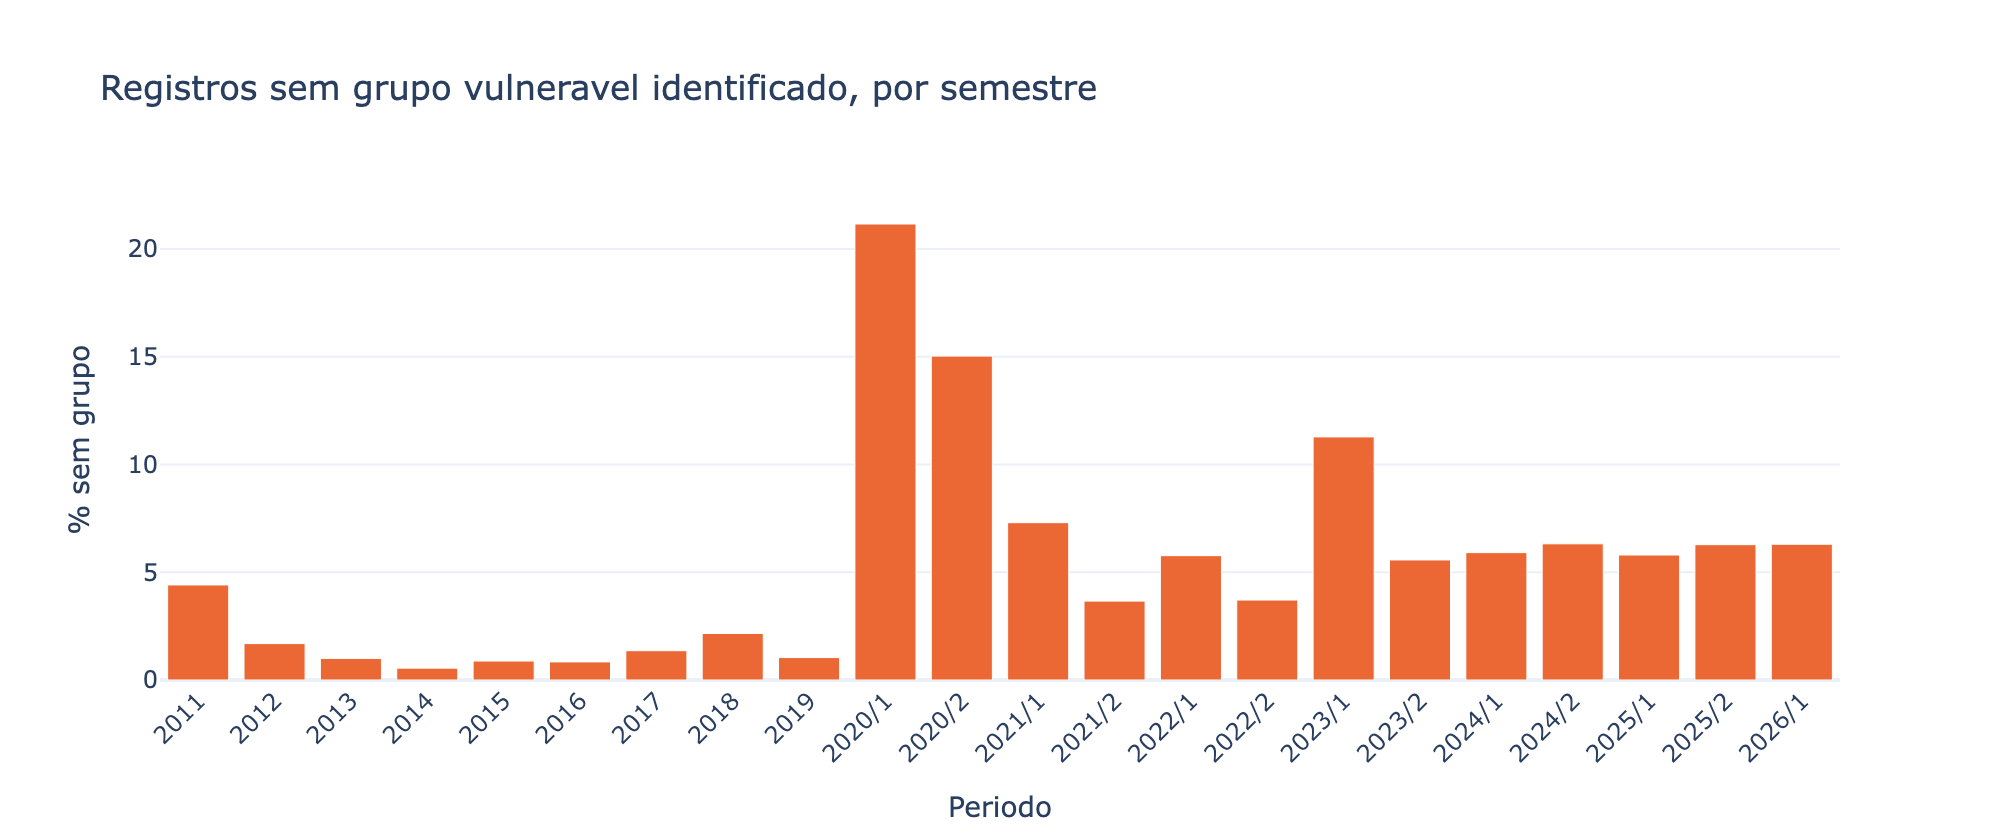

O pico em 2020/1 (21.2%) nao e mudanca de perfil das denuncias: e o arquivo daquele semestre que nao traz a coluna de grupo vulneravel, restando apenas faixa etaria, deficiencia e orientacao sexual para atribuir o grupo.


In [12]:
# O efeito da lacuna de 2023/1 sobre a proporcao sem grupo identificado.
sem_grupo = cobertura[["periodo", "pct_sem_grupo"]].copy()
fig = px.bar(
    sem_grupo, x="periodo", y="pct_sem_grupo",
    title="Registros sem grupo vulneravel identificado, por semestre",
    labels={"periodo": "Periodo", "pct_sem_grupo": "% sem grupo"},
)
fig.update_traces(marker_color="#eb6834")
fig.update_layout(xaxis_tickangle=-45)
fig.show()

pico = sem_grupo.loc[sem_grupo["pct_sem_grupo"].idxmax()]
print(
    f"O pico em {pico['periodo']} ({pico['pct_sem_grupo']:.1f}%) nao e mudanca de perfil "
    "das denuncias: e o arquivo daquele semestre que nao traz a coluna de grupo "
    "vulneravel, restando apenas faixa etaria, deficiencia e orientacao sexual para "
    "atribuir o grupo."
)

## 5. Validacao contra o balanco oficial do MDHC

Para o periodo de 2011 a 2019, os microdados nao trazem identificador de denuncia,
de modo que a contagem de denuncias nao pode ser apurada a partir deles. Existe,
porem, uma referencia externa: os balancos gerais publicados pelo proprio MDHC, que
acompanham o repositorio em `data/raw/balancos-gerais/`.

Essa comparacao e a evidencia mais direta de que registro e denuncia sao unidades
distintas, e dimensiona a diferenca no periodo em que nao ha como medi-la
internamente.

In [13]:
externa = AUDITORIA["validacao_externa_mdhc"]
oficial = pd.Series(externa["denuncias_sc_por_ano"], name="denuncias_oficiais").astype(int)
oficial.index = oficial.index.astype(int)

nossos = cobertura.groupby("ano")["registros"].sum()
comparacao = pd.DataFrame({"denuncias_balanco_mdhc": oficial}).join(
    nossos.rename("registros_violacao_projeto")
).dropna()
comparacao["registros_por_denuncia"] = (
    comparacao["registros_violacao_projeto"] / comparacao["denuncias_balanco_mdhc"]
).round(2)
comparacao.index.name = "ano"
display(comparacao)

print(f"Fonte: {externa['fonte']}")
print(f"Arquivo: {externa['arquivo']}")
print()
tot_of = int(comparacao["denuncias_balanco_mdhc"].sum())
tot_no = int(comparacao["registros_violacao_projeto"].sum())
print(f"2011 a 2019: {tot_of:,} denuncias oficiais contra {tot_no:,} registros de violacao")
print(f"Razao media: {tot_no / tot_of:.2f} registros por denuncia")

,denuncias_balanco_mdhc,registros_violacao_projeto,registros_por_denuncia
ano,,,
2011,2466,2697,1.09
2012,4233,10492,2.48
2013,5871,14106,2.40
2014,4881,11601,2.38
2015,4378,9803,2.24
2016,4250,9404,2.21
2017,4466,10118,2.27
2018,4573,9827,2.15
2019,5464,11432,2.09


Fonte: MDHC, Balanço Geral do Disque 100 de 2011 a 2019: número de denúncias por UF e módulo
Arquivo: data/raw/balancos-gerais/geral/geral_numero-de-denuncias-por-uf-por-modulo.parquet

2011 a 2019: 40,582 denuncias oficiais contra 89,480 registros de violacao
Razao media: 2.20 registros por denuncia


## 6. Triagem entre indicio penal e demanda socioassistencial

A triagem e feita por uma taxonomia de palavras-chave aplicada ao texto da violacao
relatada, em `scripts/classificar_indicio_penal.py`. Quando reconhece um tipo penal,
o pipeline marca a ocorrencia e registra a fundamentacao legal e o orgao de
encaminhamento sugerido.

Duas ressalvas que acompanham qualquer uso desses numeros:

- **Nao e decisao juridica.** Indica onde ha indicio a apurar. Nao foi validada
  contra inquerito ou laudo, e sua precisao nao foi medida.
- **A proporcao penal nao e comparavel ao longo da serie.** O vocabulario de violacao
  muda entre as eras de esquema, e com ele a fracao do texto que a taxonomia
  reconhece. A secao mede esse efeito em vez de ignora-lo.

In [14]:
categorias = consultar("""
    SELECT categoria_penal, grau_certeza, orgao_prioritario, fundamentacao_legal,
           COUNT(*) AS registros
    FROM fato_denuncias WHERE indicio_penal = 1
    GROUP BY 1, 2, 3, 4 ORDER BY registros DESC
""")
categorias["pct_do_penal"] = (
    100 * categorias["registros"] / categorias["registros"].sum()
).round(2)
categorias[["categoria_penal", "grau_certeza", "registros", "pct_do_penal", "orgao_prioritario"]]

,categoria_penal,grau_certeza,registros,pct_do_penal,orgao_prioritario
0,CRIMES_INTEGRIDADE_FISICA_E_TORTURA,ALTO,239976,55.92,POLICIA_CIVIL_E_POLICIA_CIENTIFICA
1,CRIMES_DE_AMEACA_E_COACAO,MEDIO,63444,14.78,DELEGACIA_DE_POLICIA_CIVIL
2,CRIMES_DE_ABANDONO_E_OMISSAO,MEDIO,29069,6.77,MINISTERIO_PUBLICO_E_CONSELHO_TUTELAR
3,CRIMES_SEXUAIS,ALTO,28123,6.55,DELEGACIA_ESPECIALIZADA_E_POLICIA_CIENTIFICA
4,CRIMES_CONTRA_A_HONRA_E_PRECONCEITO,MEDIO,19412,4.52,DELEGACIA_DE_POLICIA_E_MINISTERIO_PUBLICO
5,CRIMES_PATRIMONIAIS_E_FINANCEIROS,MEDIO,14390,3.35,DELEGACIA_DE_POLICIA_E_MINISTERIO_PUBLICO
6,INFRACAO_PENAL_REFUGIO_CUSTODIA_PRISIONAL_ATIVA,ALTO,12515,2.92,POLICIA_CIVIL_OU_MILITAR
7,INFRACAO_PENAL_REFUGIO_FLAGRANTE_OU_RISCO_IMIN...,ALTO,7693,1.79,POLICIA_CIVIL_OU_MILITAR
8,VIOLENCIA_PSICOLOGICA_CONTRA_MULHER,MEDIO,5077,1.18,DELEGACIA_DA_MULHER_DPCAMI
9,CRIMES_CONTRA_A_LIBERDADE_INDIVIDUAL,ALTO,4300,1.00,POLICIA_CIVIL_OU_FEDERAL


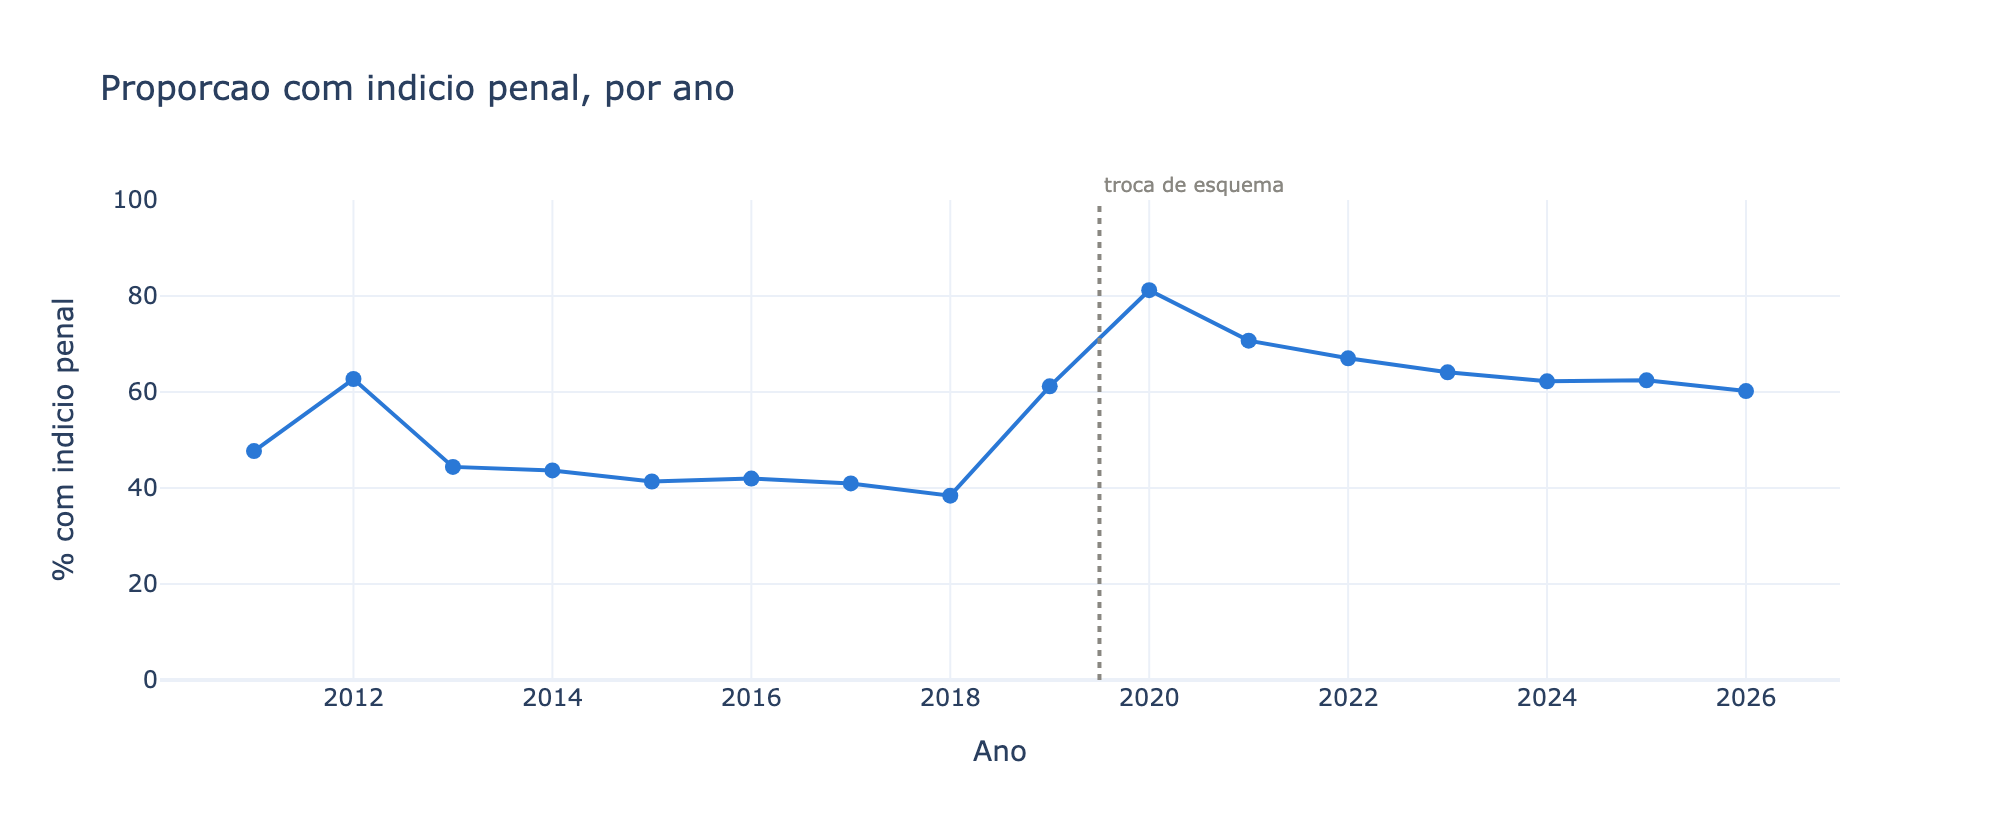

 ano  pct_penal
2011       47.7
2012       62.7
2013       44.4
2014       43.7
2015       41.4
2016       42.0
2017       41.0
2018       38.4
2019       61.2
2020       81.2
2021       70.7
2022       67.0
2023       64.1
2024       62.2
2025       62.4
2026       60.2

O salto entre 2018 e 2020 acompanha a troca de esquema dos microdados, nao uma mudanca de igual magnitude no perfil das denuncias. Comparacoes de proporcao penal devem ficar dentro de uma mesma era.


In [15]:
# Instabilidade da proporcao penal ao longo da serie.
agregado = cobertura.groupby("ano", as_index=False)[["registros", "penal"]].sum()
agregado["pct_penal"] = 100 * agregado["penal"] / agregado["registros"]
penal_ano = agregado[["ano", "pct_penal"]]

fig = px.line(
    penal_ano, x="ano", y="pct_penal", markers=True,
    title="Proporcao com indicio penal, por ano",
    labels={"ano": "Ano", "pct_penal": "% com indicio penal"},
)
fig.update_traces(line_color="#2a78d6", line_width=2, marker_size=8)
fig.update_layout(yaxis_range=[0, 100])
fig.add_vline(x=2019.5, line_dash="dot", line_color="#898781")
fig.add_annotation(x=2019.5, yref="paper", y=1.0, text="troca de esquema",
                   showarrow=False, font_size=10, font_color="#898781",
                   xanchor="left", yanchor="bottom")
fig.show()

print(penal_ano.assign(pct_penal=penal_ano["pct_penal"].round(1)).to_string(index=False))
print()
print(
    "O salto entre 2018 e 2020 acompanha a troca de esquema dos microdados, nao uma "
    "mudanca de igual magnitude no perfil das denuncias. Comparacoes de proporcao penal "
    "devem ficar dentro de uma mesma era."
)

In [16]:
# No nivel da denuncia, "penal" significa "ao menos uma violacao tipificada".
# Por isso a proporcao sobe muito em relacao a medida em registros: a medida
# comparavel e a predominancia.
decomposicao = consultar("""
    WITH d AS (
        SELECT id_denuncia, COUNT(*) AS n, SUM(indicio_penal) AS p
        FROM fato_denuncias WHERE grain_denuncia_confiavel = 1 GROUP BY 1
    )
    SELECT COUNT(*) AS denuncias,
           COUNT(*) FILTER (WHERE p = 0) AS sem_nenhum_penal,
           COUNT(*) FILTER (WHERE p > 0) AS com_algum_penal,
           COUNT(*) FILTER (WHERE p * 2 > n) AS maioria_penal,
           COUNT(*) FILTER (WHERE p = n) AS integralmente_penal
    FROM d
""").iloc[0]

total = int(decomposicao["denuncias"])
pct_registros = 100 * int(totais["registros_penal"]) / int(totais["registros_de_violacao"])
print(f"Denuncias identificaveis: {total:,}")
for rotulo, chave in [
    ("com algum indicio penal", "com_algum_penal"),
    ("com maioria penal", "maioria_penal"),
    ("integralmente penais", "integralmente_penal"),
    ("sem nenhum indicio penal", "sem_nenhum_penal"),
]:
    v = int(decomposicao[chave])
    print(f"  {rotulo:<28s} {v:>8,}  {100 * v / total:>5.1f}%")
print()
print(f"Proporcao penal medida em registros de violacao: {pct_registros:.1f}%")
print(
    "A predominancia penal por denuncia e a medida comparavel a proporcao apurada em "
    "registros; 'com algum indicio penal' responde a outra pergunta e fica muito acima."
)

Denuncias identificaveis: 95,258
  com algum indicio penal        90,449   95.0%
  com maioria penal              60,522   63.5%
  integralmente penais           17,190   18.0%
  sem nenhum indicio penal        4,809    5.0%

Proporcao penal medida em registros de violacao: 61.4%
A predominancia penal por denuncia e a medida comparavel a proporcao apurada em registros; 'com algum indicio penal' responde a outra pergunta e fica muito acima.


## 7. Demografia, taxas e o problema dos numeros pequenos

As taxas usam a populacao residente do Censo 2022 do IBGE, tabela SIDRA 4714. Duas
limitacoes acompanham esse denominador:

- e um estoque de um unico ano, aplicado a contagens de varios anos; para os anos
  mais distantes de 2022 e apenas uma aproximacao;
- em municipios pequenos, a taxa e instavel: poucas denuncias a deslocam em ordens de
  magnitude.

A segunda limitacao nao e teorica. Sem piso populacional, o topo do ranking por taxa
e ocupado por municipios de poucos milhares de habitantes, e a leitura literal do
numero chega a fracoes absurdas da populacao. O painel aplica um piso ao ranking por
taxa e ao destaque de focos no mapa, e diz isso na tela.

In [17]:
municipios = consultar("""
    SELECT ibge_code, municipio, regiao_intermediaria, populacao_censo_2022,
           total_registros, total_penal, denuncias_unicas, taxa_total_10k, taxa_penal_10k
    FROM kpis_grupos_municipios ORDER BY total_registros DESC
""")

demografia = AUDITORIA["demografia"]
print(f"Fonte: {demografia['fonte']}")
print(f"Municipios: {demografia['municipios']}")
print(f"Populacao total: {demografia['populacao_total']:,}")
print(f"Sem populacao no Censo: {demografia['municipios_sem_populacao_no_censo'] or 'nenhum'}")
print()
print("Dez municipios com maior volume de registros:")
print(municipios.head(10)[["municipio", "populacao_censo_2022", "total_registros", "taxa_total_10k"]].to_string(index=False))

Fonte: IBGE, Censo Demográfico 2022, tabela SIDRA 4714, variável 93
Municipios: 295
Populacao total: 7,610,361
Sem populacao no Censo: nenhum

Dez municipios com maior volume de registros:
     municipio  populacao_censo_2022  total_registros  taxa_total_10k
 Florianópolis                537211            65562         1220.41
     Joinville                616317            54263          880.44
      Blumenau                361261            45917         1271.02
      São José                270299            27435         1014.99
       Palhoça                222598            26732         1200.91
        Itajaí                264054            26215          992.79
         Lages                164981            23772         1440.89
       Chapecó                254785            17267          677.71
      Criciúma                214493            16791          782.82
Jaraguá do Sul                182660            15598          853.94


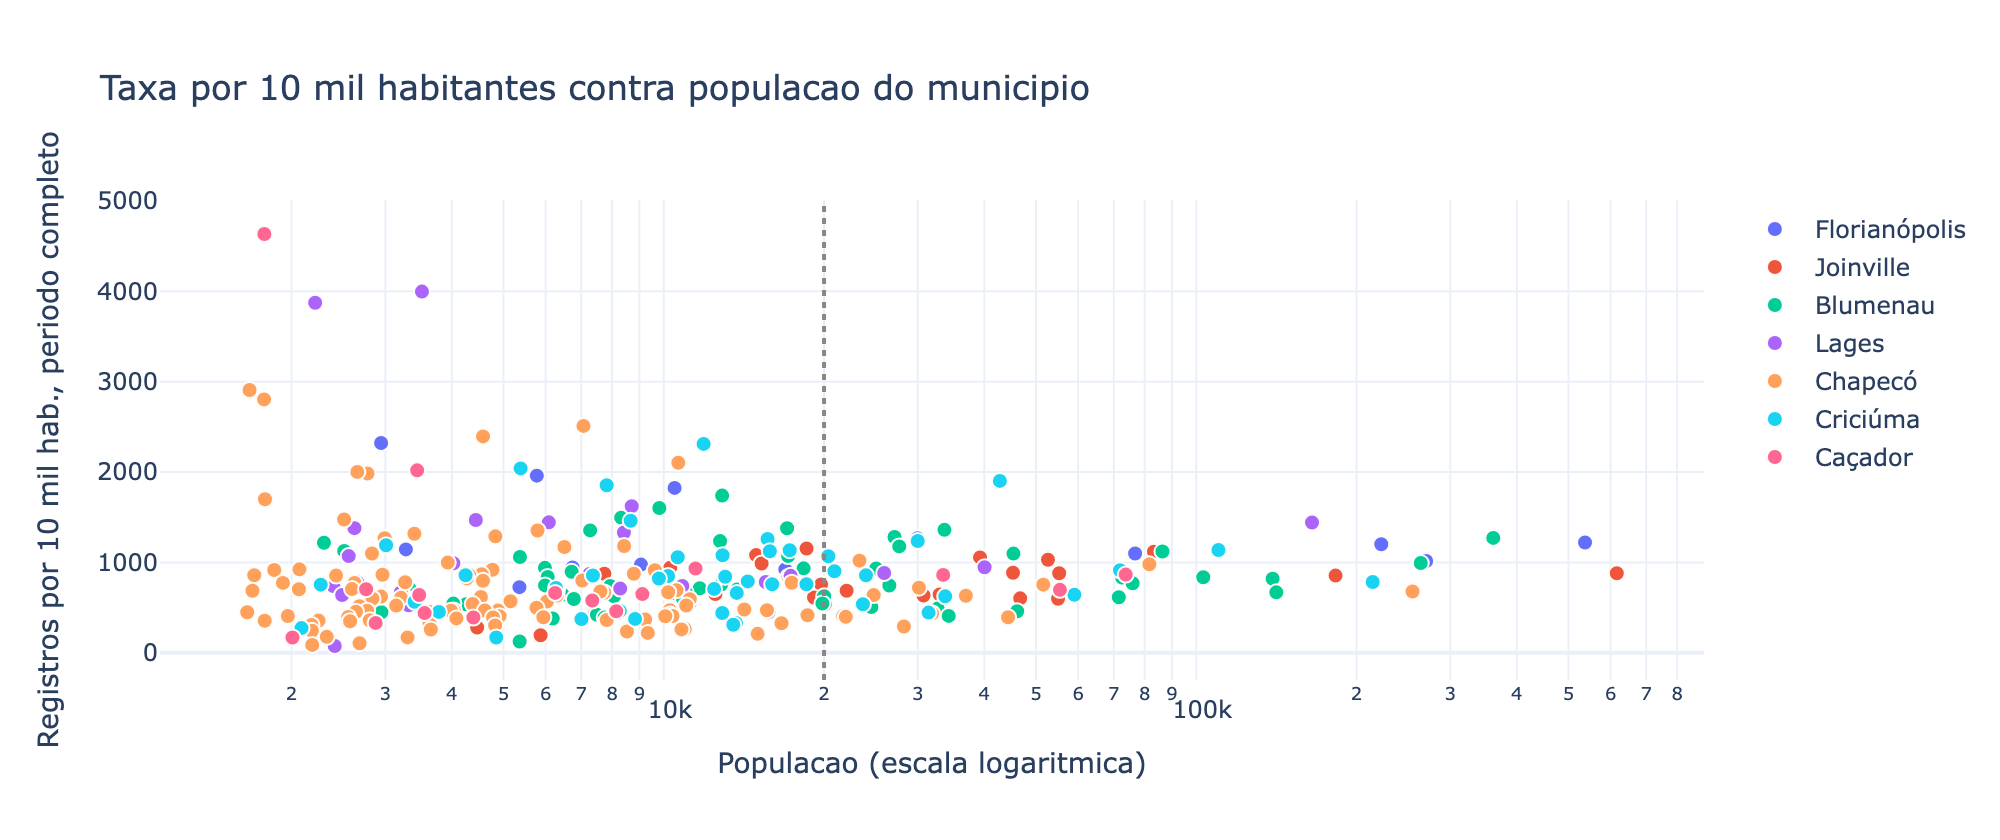

A dispersao vertical se estreita conforme a populacao cresce. Isso e o comportamento esperado de uma razao com denominador pequeno, e nao um padrao territorial a ser interpretado.


In [18]:
# Taxa contra populacao: a instabilidade aparece como um funil a esquerda.
fig = px.scatter(
    municipios, x="populacao_censo_2022", y="taxa_total_10k",
    hover_name="municipio", color="regiao_intermediaria",
    log_x=True,
    title="Taxa por 10 mil habitantes contra populacao do municipio",
    labels={
        "populacao_censo_2022": "Populacao (escala logaritmica)",
        "taxa_total_10k": "Registros por 10 mil hab., periodo completo",
        "regiao_intermediaria": "Regiao intermediaria",
    },
)
fig.update_traces(marker=dict(size=8, line=dict(width=1, color="#fcfcfb")))
fig.add_vline(x=20000, line_dash="dot", line_color="#898781")
fig.add_annotation(x=20000, yref="paper", y=1.0, text="piso de 20 mil hab.",
                   showarrow=False, font_size=10, font_color="#898781",
                   xanchor="left", yanchor="bottom")
fig.update_layout(legend_title_text="")
fig.show()

print(
    "A dispersao vertical se estreita conforme a populacao cresce. Isso e o "
    "comportamento esperado de uma razao com denominador pequeno, e nao um padrao "
    "territorial a ser interpretado."
)

In [19]:
# Efeito do piso populacional sobre o ranking por taxa.
media_estadual = (
    municipios["total_registros"].sum() / municipios["populacao_censo_2022"].sum() * 10000
)
print(f"Taxa do estado no periodo completo: {media_estadual:,.1f} por 10 mil hab.")
print()
for piso in [0, 5_000, 10_000, 20_000, 50_000]:
    elegiveis = municipios[municipios["populacao_censo_2022"] >= piso]
    topo = elegiveis.nlargest(1, "taxa_total_10k").iloc[0]
    rotulo = "sem piso" if piso == 0 else f"{piso:,} hab."
    print(
        f"  piso {rotulo:<12s} topo: {topo['municipio']:<22s} "
        f"pop {int(topo['populacao_censo_2022']):>7,}  "
        f"{topo['taxa_total_10k']:>8,.1f}/10k  "
        f"{topo['taxa_total_10k'] / media_estadual:>5.1f}x a media"
    )
print()
sem_piso = municipios.nlargest(1, "taxa_total_10k").iloc[0]
print(
    f"Sem piso, {sem_piso['municipio']} aparece com {sem_piso['taxa_total_10k']:,.0f} "
    f"registros por 10 mil habitantes, o equivalente a "
    f"{sem_piso['taxa_total_10k'] / 10000:.0%} da propria populacao ao longo do periodo. "
    "O numero esta aritmeticamente correto e nao suporta a leitura que sugere."
)

Taxa do estado no periodo completo: 916.0 por 10 mil hab.

  piso sem piso     topo: Macieira               pop   1,778   4,634.4/10k    5.1x a media
  piso 5,000 hab.   topo: Itá                    pop   7,067   2,510.3/10k    2.7x a media
  piso 10,000 hab.  topo: Imaruí                 pop  11,881   2,311.2/10k    2.5x a media
  piso 20,000 hab.  topo: Laguna                 pop  42,785   1,902.1/10k    2.1x a media
  piso 50,000 hab.  topo: Lages                  pop 164,981   1,440.9/10k    1.6x a media

Sem piso, Macieira aparece com 4,634 registros por 10 mil habitantes, o equivalente a 46% da propria populacao ao longo do periodo. O numero esta aritmeticamente correto e nao suporta a leitura que sugere.


## 8. Acesso a pericia forense

Em crimes contra a dignidade sexual e em lesoes corporais, o exame de corpo de delito
e a coleta de vestigios dependem da chegada da vitima a uma unidade da Policia
Cientifica. O projeto mede a **distancia geodesica em linha reta** entre o centroide
do municipio e a unidade mais proxima, calculada por haversine em
`scripts/gerar_geo_pci_sc.py`.

Isso nao e distancia rodoviaria e nao sustenta, por si, estimativa de tempo de
deslocamento: em relevo de serra o percurso por estrada chega a uma vez e meia a
distancia em linha reta. As faixas abaixo sao faixas de distancia, nao isocronas.

In [20]:
with open(PROCESSADOS / "sc_municipios_distancia_pci.json", encoding="utf-8") as f:
    matriz = json.load(f)

print(matriz["metadata"]["descricao"])
print()
distancias = pd.DataFrame(matriz["municipios"]).T
distancias["distancia_pci_km_linha_reta"] = distancias["distancia_pci_km_linha_reta"].astype(float)
distancias["populacao_censo_2022"] = pd.to_numeric(distancias["populacao_censo_2022"])

por_faixa = distancias.groupby("faixa_distancia").agg(
    municipios=("municipio", "count"),
    populacao=("populacao_censo_2022", "sum"),
    distancia_mediana=("distancia_pci_km_linha_reta", "median"),
).reset_index()
display(por_faixa)

print(
    f"Distancia em linha reta: minima {distancias['distancia_pci_km_linha_reta'].min():.1f} km, "
    f"mediana {distancias['distancia_pci_km_linha_reta'].median():.1f} km, "
    f"maxima {distancias['distancia_pci_km_linha_reta'].max():.1f} km"
)

Distância em linha reta entre o centroide geométrico do município e a unidade da Polícia Científica mais próxima. Não é distância rodoviária e não sustenta, por si, estimativa de tempo de deslocamento.



,faixa_distancia,municipios,populacao,distancia_mediana
0,Acima de 50 km da unidade pericial,11,77684,54.9
1,Até 25 km da unidade pericial,139,6115335,16.4
2,De 25 a 50 km da unidade pericial,145,1417342,34.0


Distancia em linha reta: minima 0.5 km, mediana 26.1 km, maxima 64.7 km


In [21]:
# Os municipios efetivamente acima de 50 km, consultados do dado.
acima = distancias[distancias["distancia_pci_km_linha_reta"] > 50].sort_values(
    "distancia_pci_km_linha_reta", ascending=False
)
print(f"{len(acima)} municipios acima de 50 km em linha reta:")
print(acima[[
    "municipio", "regiao_intermediaria", "populacao_censo_2022",
    "distancia_pci_km_linha_reta", "pci_proxima_municipio",
]].to_string(index=False))

11 municipios acima de 50 km em linha reta:
         municipio regiao_intermediaria  populacao_censo_2022  distancia_pci_km_linha_reta pci_proxima_municipio
   Santa Terezinha             Blumenau                  8066                         64.7                 Mafra
        Bom Retiro                Lages                  8418                         64.0            Rio do Sul
    Alfredo Wagner        Florianópolis                 10481                         62.8            Rio do Sul
      Rio do Campo             Blumenau                  6452                         60.0            Rio do Sul
      Praia Grande             Criciúma                  8270                         55.6             Araranguá
     Monte Castelo            Joinville                  7736                         54.9             Canoinhas
Santa Rosa de Lima             Criciúma                  2088                         53.9               Tubarão
   Doutor Pedrinho             Blumenau             

In [22]:
# Volume com indicio penal nesses municipios, para dimensionar a demanda que
# depende do deslocamento mais longo.
codigos = "', '".join(acima.index.astype(str))
demanda_distante = consultar(f"""
    SELECT municipio, populacao_censo_2022, total_registros, total_penal, taxa_penal_10k
    FROM kpis_grupos_municipios
    WHERE ibge_code IN ('{codigos}')
    ORDER BY total_penal DESC
""")
display(demanda_distante)

unidades = consultar("SELECT tipo, COUNT(*) AS unidades FROM dim_unidades_pci GROUP BY 1 ORDER BY 1")
print("Rede da Policia Cientifica de Santa Catarina:")
print(unidades.to_string(index=False))
print(f"Total: {int(unidades['unidades'].sum())} unidades")
print()
print(
    f"Os {len(acima)} municipios acima de 50 km somam "
    f"{int(demanda_distante['populacao_censo_2022'].sum()):,} habitantes e "
    f"{int(demanda_distante['total_penal'].sum()):,} registros com indicio penal no periodo, "
    f"{100 * demanda_distante['total_penal'].sum() / int(totais['registros_penal']):.1f}% do total do estado."
)

,municipio,populacao_censo_2022,total_registros,total_penal,taxa_penal_10k
0,Alfredo Wagner,10481,1912,1153,1100.09
1,Bom Retiro,8418,1120,636,755.52
2,Palmitos,15626,734,410,262.38
3,Monte Castelo,7736,677,390,504.14
4,Santa Terezinha,8066,503,309,383.09
5,Rio do Campo,6452,416,235,364.23
6,Praia Grande,8270,383,233,281.74
7,Cerro Negro,3317,174,112,337.65
8,Doutor Pedrinho,3637,133,92,252.96
9,Anitápolis,3593,142,90,250.49


Rede da Policia Cientifica de Santa Catarina:
                     tipo  unidades
          Núcleo Regional        21
Superintendência Regional         9
Total: 30 unidades

Os 11 municipios acima de 50 km somam 77,684 habitantes e 3,690 registros com indicio penal no periodo, 0.9% do total do estado.


## 9. Sintese, reconciliacao e limitacoes

As duas ultimas celulas fecham a analise: a reconciliacao verifica que os totais do
notebook, do relatorio de auditoria e das tabelas materializadas coincidem, e a
tabela de hashes permite conferir que os arquivos lidos aqui sao os mesmos que o
painel consome.

A verificacao nao e tautologica. Ela compara **contagens obtidas por caminhos
diferentes**: varredura do fato, soma da tabela agregada por municipio e o que o
relatorio de auditoria registrou no momento do processamento. Divergencia entre elas
indicaria erro de agregacao.

In [23]:
fato = consultar("""
    SELECT COUNT(*) AS registros, SUM(indicio_penal) AS penal,
           COUNT(DISTINCT CASE WHEN grain_denuncia_confiavel = 1 THEN id_denuncia END) AS denuncias
    FROM fato_denuncias
""").iloc[0]
kpi = consultar("""
    SELECT SUM(total_registros) AS registros, SUM(total_penal) AS penal,
           SUM(denuncias_unicas) AS denuncias FROM kpis_grupos_municipios
""").iloc[0]
kpi_ano = consultar("""
    SELECT SUM(total_denuncias) AS registros, SUM(total_penal) AS penal,
           SUM(denuncias_unicas) AS denuncias FROM kpis_grupos_municipios_ano
""").iloc[0]

reconciliacao = pd.DataFrame({
    "fato_denuncias": [int(fato["registros"]), int(fato["penal"]), int(fato["denuncias"])],
    "kpis_por_municipio": [int(kpi["registros"]), int(kpi["penal"]), int(kpi["denuncias"])],
    "kpis_por_municipio_ano": [int(kpi_ano["registros"]), int(kpi_ano["penal"]), int(kpi_ano["denuncias"])],
    "relatorio_auditoria": [
        int(totais["registros_de_violacao"]), int(totais["registros_penal"]),
        int(totais["denuncias_unicas_identificaveis"]),
    ],
}, index=["registros_violacao", "com_indicio_penal", "denuncias_unicas"])
display(reconciliacao)

conciliacao = AUDITORIA["conciliacao_municipal"]
print(
    f"A diferenca entre o fato e as tabelas municipais e de "
    f"{conciliacao['registros_sem_municipio_identificado']:,} registros sem municipio "
    "identificado, excluidos dos indicadores municipais porque nao ha municipio a que "
    "atribui-los."
)
print()
print(
    "As duas tabelas de KPI batem entre si e com o fato descontada essa diferenca; as "
    "denuncias unicas somadas por municipio ficam ligeiramente abaixo do total distinto "
    "porque dez denuncias aparecem em mais de um municipio."
)

,fato_denuncias,kpis_por_municipio,kpis_por_municipio_ano,relatorio_auditoria
registros_violacao,699029,697090,697090,699029
com_indicio_penal,429137,427986,427986,429137
denuncias_unicas,95258,94876,94876,95258


A diferenca entre o fato e as tabelas municipais e de 1,939 registros sem municipio identificado, excluidos dos indicadores municipais porque nao ha municipio a que atribui-los.

As duas tabelas de KPI batem entre si e com o fato descontada essa diferenca; as denuncias unicas somadas por municipio ficam ligeiramente abaixo do total distinto porque dez denuncias aparecem em mais de um municipio.


In [24]:
import hashlib

print("Integridade dos artefatos lidos por este notebook e pelo painel:")
print()
ok = 0
for nome, esperado in AUDITORIA["arquivos_hashes_sha256"].items():
    caminho = PROCESSADOS / nome
    if not caminho.exists():
        print(f"  ausente   {nome}")
        continue
    real = hashlib.sha256(caminho.read_bytes()).hexdigest()
    confere = real == esperado
    ok += confere
    print(f"  {'confere' if confere else 'DIVERGE':<9s} {nome:<44s} {real[:16]}...")
print()
print(f"{ok} de {len(AUDITORIA['arquivos_hashes_sha256'])} arquivos conferem.")
print()
print("Limitacoes conhecidas, conforme o relatorio de auditoria:")
for i, item in enumerate(AUDITORIA["limitacoes_conhecidas"], 1):
    print(f"  {i}. {item}")
con.close()

Integridade dos artefatos lidos por este notebook e pelo painel:

  confere   sc_censo_2022_populacao.json                 ba2e55c70607cd8a...
  confere   sc_dim_municipios.parquet                    9d920fd39e9023dd...
  confere   sc_dim_pci.parquet                           f2e6a4a6cafc8f0c...
  confere   sc_distribuicao_penal_dados.js               d9a9907f82d6243a...
  confere   sc_distribuicao_penal_metricas.json          ef64b710319023f3...
  confere   sc_eixos_rodoviarios.json                    098ecb54e63f35b2...
  confere   sc_fato_denuncias.parquet                    4d161aaa9cd18fec...
  confere   sc_kpis_categoria_penal.parquet              28dd9d51a8c4da7b...
  confere   sc_kpis_grupos_municipios.csv                6cd329f4d6595638...
  confere   sc_kpis_grupos_municipios.parquet            6d235cd5ecb208bd...
  confere   sc_kpis_grupos_municipios_ano.parquet        fcf824f385f06de9...
  confere   sc_malha_municipios.geojson                  0a06617bc159fd43...
  confere 

## Fontes

| Fonte | Conteudo |
| :--- | :--- |
| [MDHC / Ouvidoria Nacional de Direitos Humanos](https://www.gov.br/mdh/pt-br/ondh) | Microdados abertos do Disque 100, 2011 a 2026, e balancos tematicos |
| [IBGE, Censo Demografico 2022, tabela 4714](https://sidra.ibge.gov.br/tabela/4714) | Populacao residente dos 295 municipios de Santa Catarina |
| [IBGE, API de Malhas](https://servicodados.ibge.gov.br/api/docs/malhas) | Malha vetorial municipal e divisao regional de 2017 |
| [Policia Cientifica de Santa Catarina](https://www.policiacientifica.sc.gov.br/unidades/) | Catalogo das 30 unidades: 9 superintendencias e 21 nucleos |
| [MDS, SUAS](https://www.gov.br/mds/pt-br/acoes-e-programas/suas) | Tipificacao Nacional de Servicos Socioassistenciais, Resolucao CNAS 109/2009 |

Grupo 03, Ciencia de Dados, UFSC.